## Import Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load Data

In [3]:
# 1. Memuat dataset
df = pd.read_csv('/kaggle/input/datasets/shaistashahid/world-famous-places/world_famous_places_2024.csv')

# 2. Melihat 5 baris pertama untuk memahami struktur data
print("--- 5 Baris Pertama Data ---")
display(df.head())

# 3. Mengecek informasi kolom dan tipe data (apakah ada nilai null?)
print("\n--- Informasi Dataset ---")
df.info()

--- 5 Baris Pertama Data ---


,Place_Name,Country,City,Annual_Visitors_Millions,Type,UNESCO_World_Heritage,Year_Built,Entry_Fee_USD,Best_Visit_Month,Region,Tourism_Revenue_Million_USD,Average_Visit_Duration_Hours,Famous_For
0,Eiffel Tower,France,Paris,7.0,Monument/Tower,No,1889,35,May-June/Sept-Oct,Western Europe,95,2.5,"Iconic iron lattice tower, symbol of Paris"
1,Times Square,United States,New York City,50.0,Urban Landmark,No,1904,0,Apr-June/Sept-Nov,North America,70,1.5,"Bright lights, Broadway shows, New Year's Eve ..."
2,Louvre Museum,France,Paris,8.7,Museum,Yes,1793,22,Oct-March,Western Europe,120,4.0,"World's most visited museum, home to Mona Lisa"
3,Great Wall of China,China,Beijing/Multiple,10.0,Historic Monument,Yes,220 BC - 1644 AD,10,Apr-May/Sept-Oct,East Asia,180,4.0,Ancient defensive structure visible from space
4,Taj Mahal,India,Agra,7.5,Monument/Mausoleum,Yes,1653,15,Oct-March,South Asia,65,2.0,"White marble mausoleum, symbol of love"



--- Informasi Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Place_Name                    30 non-null     object 
 1   Country                       30 non-null     object 
 2   City                          30 non-null     object 
 3   Annual_Visitors_Millions      30 non-null     float64
 4   Type                          30 non-null     object 
 5   UNESCO_World_Heritage         30 non-null     object 
 6   Year_Built                    30 non-null     object 
 7   Entry_Fee_USD                 30 non-null     int64  
 8   Best_Visit_Month              30 non-null     object 
 9   Region                        30 non-null     object 
 10  Tourism_Revenue_Million_USD   30 non-null     int64  
 11  Average_Visit_Duration_Hours  30 non-null     float64
 12  Famous_For                    30 non-nu

Pada tahap ini, kita mengimpor pustaka (library) utama yaitu Pandas untuk manipulasi data, serta Matplotlib dan Seaborn untuk visualisasi. Pemanggilan fungsi info() sangat esensial untuk memverifikasi struktur dataset, mendeteksi keberadaan nilai yang kosong (missing values), dan memastikan bahwa setiap variabel telah terbaca dengan tipe data yang tepat (misalnya, variabel harga berbentuk numerik, bukan teks).

## Statistik Deskriptif

In [4]:
# 1. Menampilkan ringkasan statistik untuk kolom numerik
print("--- Statistik Deskriptif ---")
display(df.describe())

# 2. Mengidentifikasi destinasi dengan pengunjung terbanyak dan paling sedikit
max_visitors = df[df['Annual_Visitors_Millions'] == df['Annual_Visitors_Millions'].max()][['Place_Name', 'Annual_Visitors_Millions']]
min_visitors = df[df['Annual_Visitors_Millions'] == df['Annual_Visitors_Millions'].min()][['Place_Name', 'Annual_Visitors_Millions']]

print("\nDestinasi dengan Pengunjung Terbanyak:\n", max_visitors)
print("\nDestinasi dengan Pengunjung Paling Sedikit:\n", min_visitors)

--- Statistik Deskriptif ---


,Annual_Visitors_Millions,Entry_Fee_USD,Tourism_Revenue_Million_USD,Average_Visit_Duration_Hours
count,30.000000,30.000000,30.000000,30.000000
mean,11.331667,24.600000,593.500000,3.166667
std,12.044247,28.572473,1521.481894,2.499425
min,1.500000,0.000000,25.000000,0.500000
25%,4.775000,0.000000,61.250000,1.500000
50%,7.575000,19.000000,87.500000,2.250000
75%,12.250000,35.000000,167.500000,4.000000
max,50.000000,109.000000,6800.000000,10.000000



Destinasi dengan Pengunjung Terbanyak:
      Place_Name  Annual_Visitors_Millions
1  Times Square                      50.0

Destinasi dengan Pengunjung Paling Sedikit:
      Place_Name  Annual_Visitors_Millions
8  Machu Picchu                       1.5


Fungsi describe() menyajikan metrik statistik penting seperti nilai rata-rata (mean), nilai tengah (median), serta rentang data (nilai minimum dan maksimum) untuk variabel seperti jumlah pengunjung, biaya masuk, dan pendapatan pariwisata. Filter tambahan diterapkan untuk mengidentifikasi secara spesifik destinasi mana yang menempati posisi tertinggi dan terendah dalam hal volume pengunjung.

## Agregasi Data

In [5]:
# 1. Analisis rata-rata Pendapatan dan Pengunjung berdasarkan Wilayah (Region)
region_stats = df.groupby('Region')[['Annual_Visitors_Millions', 'Tourism_Revenue_Million_USD']].mean().reset_index()
region_stats = region_stats.sort_values(by='Tourism_Revenue_Million_USD', ascending=False)

print("--- Rata-rata Pengunjung & Pendapatan per Wilayah (Region) ---")
display(region_stats)

# 2. Analisis komparasi harga tiket: UNESCO vs Non-UNESCO
unesco_compare = df.groupby('UNESCO_World_Heritage')['Entry_Fee_USD'].mean().reset_index()
print("\n--- Rata-rata Harga Tiket: Warisan UNESCO vs Non-UNESCO ---")
display(unesco_compare)

--- Rata-rata Pengunjung & Pendapatan per Wilayah (Region) ---


,Region,Annual_Visitors_Millions,Tourism_Revenue_Million_USD
3,North America,20.5100,1565.0
1,Middle East,6.0000,350.0
0,East Asia,9.5000,127.5
4,Oceania,8.2000,110.0
5,South America,1.8500,107.5
9,Western Europe,9.1000,100.0
7,Southeast Asia,2.6000,90.0
8,Southern Europe,5.3375,82.5
6,South Asia,7.5000,65.0
2,North Africa,2.8000,40.0



--- Rata-rata Harga Tiket: Warisan UNESCO vs Non-UNESCO ---


,UNESCO_World_Heritage,Entry_Fee_USD
0,No,26.846154
1,Yes,22.882353


Metode groupby() merupakan fungsi fundamental dalam analisis data untuk agregasi. Melalui kode di atas, kita dapat mengevaluasi kinerja setiap wilayah geografis (Region) berdasarkan rata-rata pendapatan yang dihasilkan. Selain itu, kita juga dapat menguji hipotesis sederhana, misalnya, apakah destinasi yang memiliki status Warisan Dunia UNESCO menetapkan harga tiket masuk yang secara rata-rata lebih tinggi dibandingkan yang tidak.

## Visualisasi Data

/tmp/ipykernel_58/1469511142.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_places, x='Annual_Visitors_Millions', y='Place_Name', palette='viridis', ax=axes[0])


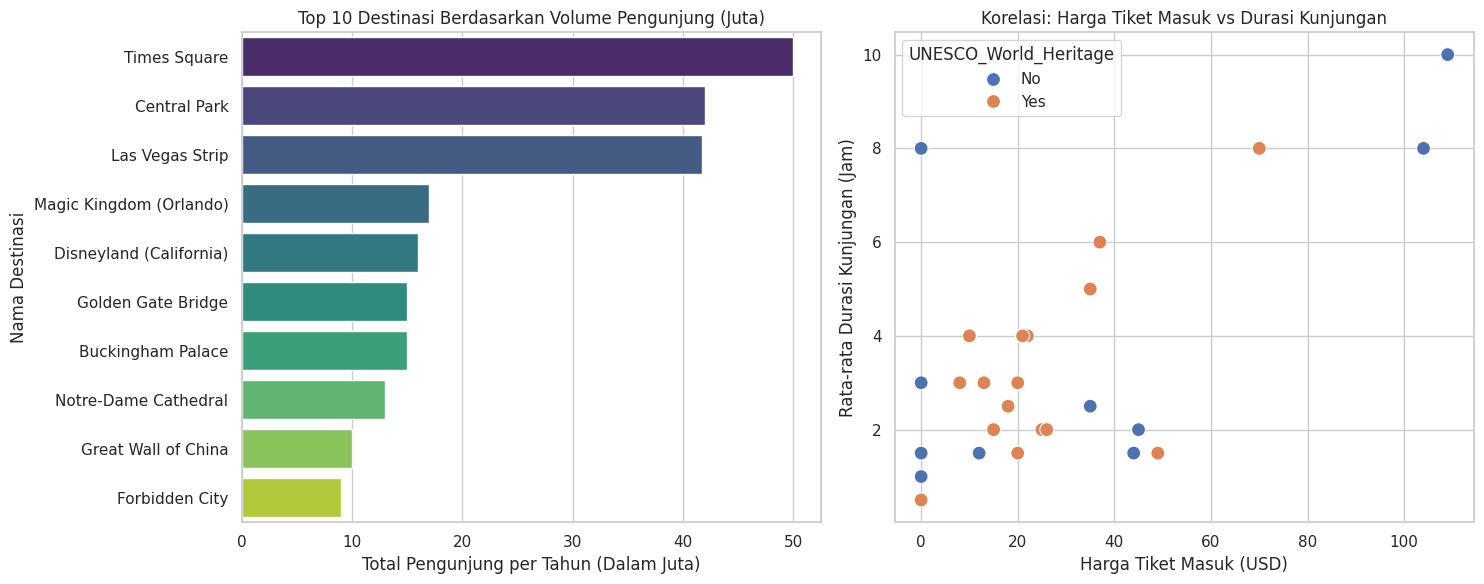

In [6]:
# Konfigurasi gaya visualisasi
sns.set_theme(style="whitegrid")

# Membuat area gambar (canvas) dengan 2 grafik berdampingan
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Grafik 1: Top 10 Destinasi Berdasarkan Jumlah Pengunjung
top_10_places = df.nlargest(10, 'Annual_Visitors_Millions')
sns.barplot(data=top_10_places, x='Annual_Visitors_Millions', y='Place_Name', palette='viridis', ax=axes[0])
axes[0].set_title('Top 10 Destinasi Berdasarkan Volume Pengunjung (Juta)')
axes[0].set_xlabel('Total Pengunjung per Tahun (Dalam Juta)')
axes[0].set_ylabel('Nama Destinasi')

# Grafik 2: Hubungan antara Harga Tiket dan Durasi Kunjungan
sns.scatterplot(data=df, x='Entry_Fee_USD', y='Average_Visit_Duration_Hours', hue='UNESCO_World_Heritage', s=100, ax=axes[1])
axes[1].set_title('Korelasi: Harga Tiket Masuk vs Durasi Kunjungan')
axes[1].set_xlabel('Harga Tiket Masuk (USD)')
axes[1].set_ylabel('Rata-rata Durasi Kunjungan (Jam)')

plt.tight_layout()
plt.show()

- Grafik Batang (Bar Chart): Digunakan pada panel kiri untuk membandingkan kategori secara kategorikal. Hal ini memudahkan pembaca dalam melihat peringkat 10 destinasi dengan performa volume pengunjung terbaik.

- Diagram Pencar (Scatter Plot): Digunakan pada panel kanan untuk mendeteksi apakah terdapat pola atau korelasi antara harga tiket yang dibayarkan wisatawan dengan lamanya waktu yang dihabiskan di destinasi tersebut. Penggunaan parameter hue berdasarkan status UNESCO memberikan dimensi tambahan pada analisis visual.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [8]:
print("\n--- Struktur Data dan Pengecekan Nilai Kosong (Missing Values) ---")
df.info()


--- Struktur Data dan Pengecekan Nilai Kosong (Missing Values) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Place_Name                    30 non-null     object 
 1   Country                       30 non-null     object 
 2   City                          30 non-null     object 
 3   Annual_Visitors_Millions      30 non-null     float64
 4   Type                          30 non-null     object 
 5   UNESCO_World_Heritage         30 non-null     object 
 6   Year_Built                    30 non-null     object 
 7   Entry_Fee_USD                 30 non-null     int64  
 8   Best_Visit_Month              30 non-null     object 
 9   Region                        30 non-null     object 
 10  Tourism_Revenue_Million_USD   30 non-null     int64  
 11  Average_Visit_Duration_Hours  30 non-null     float64
 12

## Rekayasa Indikator Kinerja Utama (KPI Engineering)

In [9]:
# Membuat metrik baru: Estimasi pendapatan per satu juta pengunjung (dalam juta USD)
df['Revenue_Per_Visitor_USD'] = df['Tourism_Revenue_Million_USD'] / df['Annual_Visitors_Millions']

# Menampilkan 5 destinasi dengan efisiensi pendapatan tertinggi
top_efficient = df.sort_values(by='Revenue_Per_Visitor_USD', ascending=False)[
    ['Place_Name', 'Country', 'Annual_Visitors_Millions', 'Tourism_Revenue_Million_USD', 'Revenue_Per_Visitor_USD']
].head(5)

print("--- Top 5 Destinasi dengan Efisiensi Pendapatan Tertinggi ---")
print(top_efficient)

--- Top 5 Destinasi dengan Efisiensi Pendapatan Tertinggi ---
                 Place_Name        Country  Annual_Visitors_Millions  \
19  Magic Kingdom (Orlando)  United States                      17.0   
18  Disneyland (California)  United States                      16.0   
13          Las Vegas Strip  United States                      41.7   
20             Grand Canyon  United States                       6.0   
8              Machu Picchu           Peru                       1.5   

    Tourism_Revenue_Million_USD  Revenue_Per_Visitor_USD  
19                         4500               264.705882  
18                         3200               200.000000  
13                         6800               163.069544  
20                          780               130.000000  
8                           180               120.000000  


## Analisis Deskriptif dan Agregasi Regional

In [10]:
print("--- Ringkasan Statistik Deskriptif Umum ---")
print(df.describe())

# Mengidentifikasi nilai ekstrem pada volume pengunjung
max_visitors = df[df['Annual_Visitors_Millions'] == df['Annual_Visitors_Millions'].max()][['Place_Name', 'Annual_Visitors_Millions']]
min_visitors = df[df['Annual_Visitors_Millions'] == df['Annual_Visitors_Millions'].min()][['Place_Name', 'Annual_Visitors_Millions']]

print("\nDestinasi dengan Pengunjung Terbanyak:\n", max_visitors)
print("\nDestinasi dengan Pengunjung Paling Sedikit:\n", min_visitors)

# Agregasi data pariwisata berdasarkan Wilayah (Region)
region_stats = df.groupby('Region')[['Annual_Visitors_Millions', 'Tourism_Revenue_Million_USD', 'Revenue_Per_Visitor_USD']].mean().reset_index()
region_stats = region_stats.sort_values(by='Tourism_Revenue_Million_USD', ascending=False)

print("\n--- Rata-rata Kinerja Pariwisata per Wilayah (Region) ---")
print(region_stats)

--- Ringkasan Statistik Deskriptif Umum ---
       Annual_Visitors_Millions  Entry_Fee_USD  Tourism_Revenue_Million_USD  \
count                 30.000000      30.000000                    30.000000   
mean                  11.331667      24.600000                   593.500000   
std                   12.044247      28.572473                  1521.481894   
min                    1.500000       0.000000                    25.000000   
25%                    4.775000       0.000000                    61.250000   
50%                    7.575000      19.000000                    87.500000   
75%                   12.250000      35.000000                   167.500000   
max                   50.000000     109.000000                  6800.000000   

       Average_Visit_Duration_Hours  Revenue_Per_Visitor_USD  
count                     30.000000                30.000000  
mean                       3.166667                41.492561  
std                        2.499425                65.7

## Analisis Korelasi Antar-Variabel

In [11]:
# Memilih variabel numerik kunci
numeric_columns = ['Annual_Visitors_Millions', 'Entry_Fee_USD', 'Tourism_Revenue_Million_USD', 'Average_Visit_Duration_Hours', 'Revenue_Per_Visitor_USD']
correlation_matrix = df[numeric_columns].corr()

print("--- Matriks Korelasi Pearson Antar-Variabel ---")
print(correlation_matrix)

--- Matriks Korelasi Pearson Antar-Variabel ---
                              Annual_Visitors_Millions  Entry_Fee_USD  \
Annual_Visitors_Millions                      1.000000      -0.208015   
Entry_Fee_USD                                -0.208015       1.000000   
Tourism_Revenue_Million_USD                   0.444269       0.378346   
Average_Visit_Duration_Hours                  0.159640       0.685167   
Revenue_Per_Visitor_USD                       0.161157       0.759515   

                              Tourism_Revenue_Million_USD  \
Annual_Visitors_Millions                         0.444269   
Entry_Fee_USD                                    0.378346   
Tourism_Revenue_Million_USD                      1.000000   
Average_Visit_Duration_Hours                     0.722080   
Revenue_Per_Visitor_USD                          0.818852   

                              Average_Visit_Duration_Hours  \
Annual_Visitors_Millions                          0.159640   
Entry_Fee_USD         

## Visualisasi Data Terintegrasi (Dashboard)

/tmp/ipykernel_58/2374583715.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_places, x='Annual_Visitors_Millions', y='Place_Name', palette='viridis', ax=axes[0, 0])
/tmp/ipykernel_58/2374583715.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Region', y='Entry_Fee_USD', palette='Set3', ax=axes[1, 1])
/tmp/ipykernel_58/2374583715.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=30, ha='right')


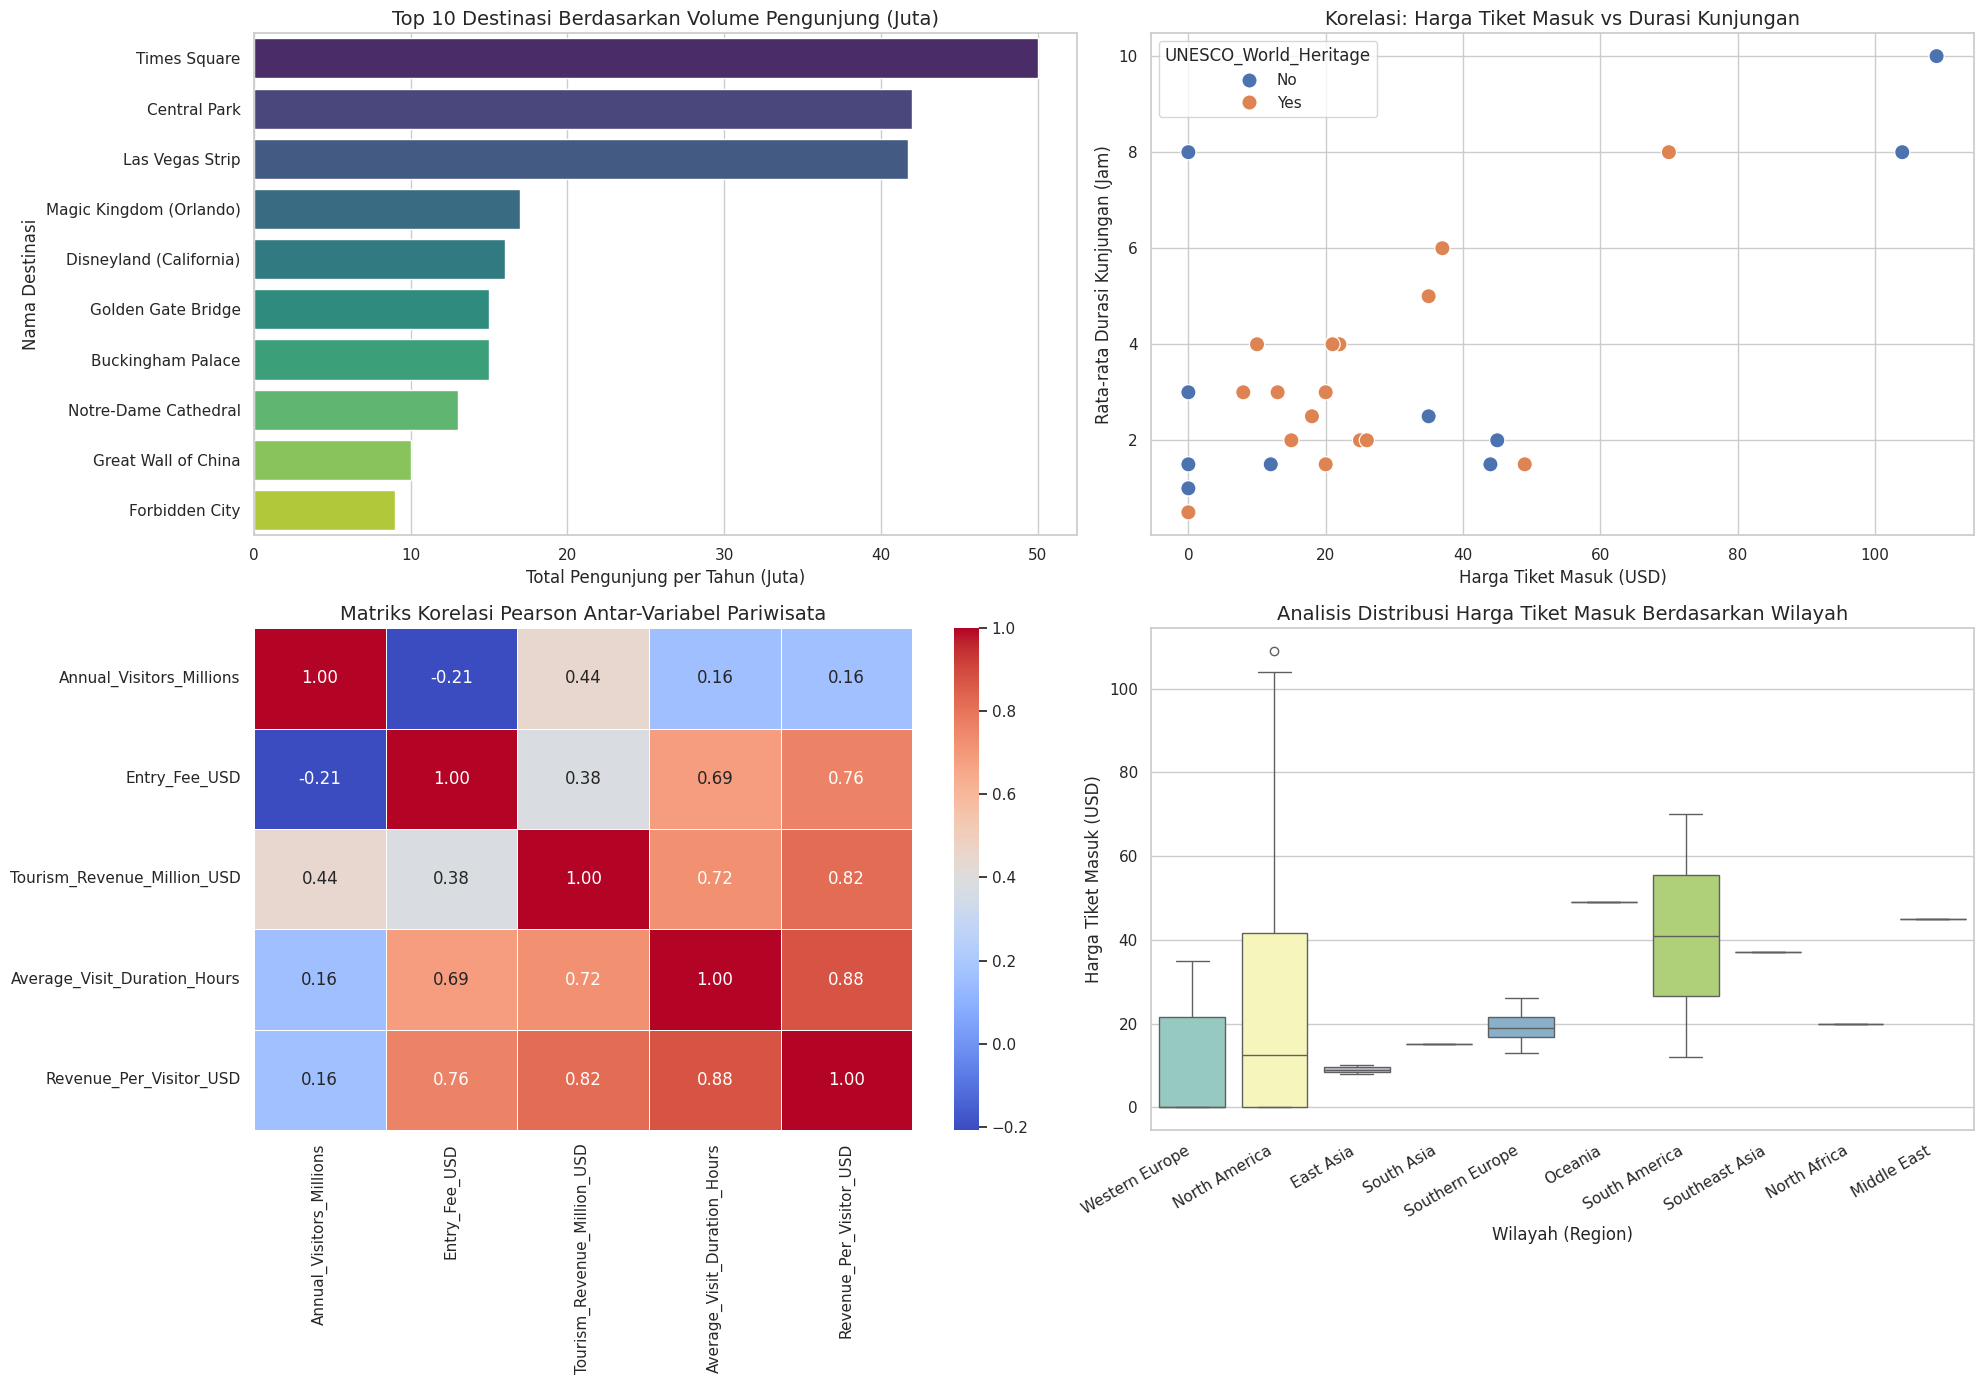

In [12]:
# Mengonfigurasi gaya visualisasi grafik
sns.set_theme(style="whitegrid")

# Membuat tata letak 2x2 (4 grafik dalam satu kanvas)
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# Grafik 1: Top 10 Destinasi Berdasarkan Jumlah Pengunjung
top_10_places = df.nlargest(10, 'Annual_Visitors_Millions')
sns.barplot(data=top_10_places, x='Annual_Visitors_Millions', y='Place_Name', palette='viridis', ax=axes[0, 0])
axes[0, 0].set_title('Top 10 Destinasi Berdasarkan Volume Pengunjung (Juta)', fontsize=14)
axes[0, 0].set_xlabel('Total Pengunjung per Tahun (Juta)')
axes[0, 0].set_ylabel('Nama Destinasi')

# Grafik 2: Scatter Plot Hubungan Harga Tiket vs Durasi Kunjungan
sns.scatterplot(data=df, x='Entry_Fee_USD', y='Average_Visit_Duration_Hours', hue='UNESCO_World_Heritage', s=120, ax=axes[0, 1])
axes[0, 1].set_title('Korelasi: Harga Tiket Masuk vs Durasi Kunjungan', fontsize=14)
axes[0, 1].set_xlabel('Harga Tiket Masuk (USD)')
axes[0, 1].set_ylabel('Rata-rata Durasi Kunjungan (Jam)')

# Grafik 3: Heatmap Korelasi Antar-Variabel
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, ax=axes[1, 0])
axes[1, 0].set_title('Matriks Korelasi Pearson Antar-Variabel Pariwisata', fontsize=14)

# Grafik 4: Boxplot Distribusi Biaya Masuk Berdasarkan Wilayah
sns.boxplot(data=df, x='Region', y='Entry_Fee_USD', palette='Set3', ax=axes[1, 1])
axes[1, 1].set_title('Analisis Distribusi Harga Tiket Masuk Berdasarkan Wilayah', fontsize=14)
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=30, ha='right')
axes[1, 1].set_xlabel('Wilayah (Region)')
axes[1, 1].set_ylabel('Harga Tiket Masuk (USD)')

# Penyesuaian jarak antar-grafik agar rapi
plt.tight_layout()
plt.show()